# Comment Feature Extraction
*Extracting per-permit features from `plan_comments.csv` for use in the Random Forest model*

**Goal:** Produce a single row per permit containing structural and text-derived features that can be joined onto `master_dataset.csv` to enrich the modeling population.

**Coverage note:** Only 707 of 14,201 permits have comment records (~5%). Comment features will be null for the remaining 95% and will be median-imputed by the model pipeline. Despite low coverage, these permits skew toward longer, more complex reviews and may carry meaningful signal.

**Features extracted:**

*Structural (from ReviewCycle, ReviewType, Subject):*
- `comment_max_cycle` — maximum review cycle number (direct complexity proxy)
- `comment_n_rows` — total number of comment rows (volume of corrections)
- `comment_n_distinct_cycles` — number of distinct review cycles
- `comment_n_review_types` — number of distinct review types
- `comment_n_subjects` — number of distinct correction subjects
- `comment_has_structural` — flag: Structural Engineer review present
- `comment_has_eca` — flag: any ECA (Environmentally Critical Area) review present
- `comment_has_fire` — flag: Fire review present
- `comment_has_design_review` — flag: Design Review present
- `comment_has_geotech` — flag: ECA GeoTech or Geo Soils review present

*Text-derived (from Comment field):*
- `comment_avg_length` — average comment length in characters (proxy for correction complexity)
- `comment_repeated_correction_rate` — fraction of comments containing 'repeated correction'
- `comment_unresolved_rate` — fraction containing 'not resolved' or 'not addressed'
- `comment_partial_rate` — fraction containing 'partially resolved'
- `comment_resubmit_rate` — fraction containing 'resubmit' or 'revise'
- `comment_tfidf_*` — top TF-IDF (Term Frequency-Inverse Document Frequency) features across the permit's comment corpus

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

# Notebook runs from: notebooks/
# Data lives in:      ../data/
# Output goes to:     ../output/
DATA_DIR   = Path('C:\\Users\\flori\\Documents\\GitHub\\CSB425-City-of-Seattle-Permit-Predictor\\data')
OUTPUT_DIR = Path('C:\\Users\\flori\\Documents\\GitHub\\CSB425-City-of-Seattle-Permit-Predictor\\output')

print('plan_comments.csv exists:', (DATA_DIR / 'plan_comments.csv').exists())
print('master_dataset.csv exists:', (DATA_DIR / 'master_dataset.csv').exists())

plan_comments.csv exists: True
master_dataset.csv exists: True


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_DIR / 'plan_comments.csv')

print(f'Rows         : {len(df):,}')
print(f'Unique permits: {df["PermitNum"].nunique():,}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNull counts:')
print(df.isnull().sum())

Rows         : 26,299
Unique permits: 707

Columns: ['PermitNum', 'DocumentTitle', 'URL', 'Subject', 'ReviewType', 'ReviewCycle', 'Comment', 'DocumentDate']

Null counts:
PermitNum           0
DocumentTitle       0
URL                 0
Subject             0
ReviewType        342
ReviewCycle      1606
Comment            63
DocumentDate        0
dtype: int64


## 2. Clean & Normalize

In [3]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'permitnum': 'permitnum'})

# Normalize text fields
df['reviewtype'] = df['reviewtype'].fillna('Unknown').str.strip()
df['subject']    = df['subject'].fillna('Unknown').str.strip()
df['comment']    = df['comment'].fillna('')
df['comment_lower'] = df['comment'].str.lower()

# ReviewCycle: coerce to numeric, fill nulls with 1 (most common)
df['reviewcycle'] = pd.to_numeric(df['reviewcycle'], errors='coerce').fillna(1).astype(int)

print('Cleaned. Sample:')
df[['permitnum', 'reviewtype', 'reviewcycle', 'subject', 'comment']].head(3)

Cleaned. Sample:


,permitnum,reviewtype,reviewcycle,subject,comment
0,6524888-CN,Structural Engineer,2,00 Code Edition,This project has been reviewed for conformance...
1,6524888-CN,Structural Engineer,2,16 Gravity Design,"Section S4.3, please confirm double wall top p..."
2,6524888-CN,Structural Engineer,2,16 Lateral Design,"Section 7,8/S4.1, for force transfered around ..."


## 3. Structural Features

Aggregated per permit from `ReviewCycle`, `ReviewType`, and `Subject`.

In [4]:
# ── High-complexity review type flags ──────────────────────────────
df['is_structural']    = df['reviewtype'].str.contains('Structural Engineer',    case=False, na=False).astype(int)
df['is_eca']           = df['reviewtype'].str.contains('ECA|Geo|Floodplain|Riparian|Wetland|Wildlife', case=False, na=False).astype(int)
df['is_fire']          = df['reviewtype'].str.contains('Fire',                   case=False, na=False).astype(int)
df['is_design_review'] = df['reviewtype'].str.contains('Design Review',          case=False, na=False).astype(int)
df['is_geotech']       = df['reviewtype'].str.contains('GeoTech|Geo Soils',      case=False, na=False).astype(int)

# ── Aggregate to one row per permit ───────────────────────────────
structural = df.groupby('permitnum').agg(
    comment_n_rows            = ('comment',        'count'),
    comment_max_cycle         = ('reviewcycle',    'max'),
    comment_n_distinct_cycles = ('reviewcycle',    'nunique'),
    comment_n_review_types    = ('reviewtype',     'nunique'),
    comment_n_subjects        = ('subject',        'nunique'),
    comment_has_structural    = ('is_structural',  'max'),
    comment_has_eca           = ('is_eca',         'max'),
    comment_has_fire          = ('is_fire',        'max'),
    comment_has_design_review = ('is_design_review','max'),
    comment_has_geotech       = ('is_geotech',     'max'),
).reset_index()

print(f'Structural features shape: {structural.shape}')
print(structural.describe().round(2))

Structural features shape: (707, 11)
       comment_n_rows  comment_max_cycle  comment_n_distinct_cycles  \
count          707.00             707.00                     707.00   
mean            37.20               2.47                       2.43   
std             30.13               1.28                       1.20   
min              1.00               1.00                       1.00   
25%             17.00               2.00                       2.00   
50%             31.00               2.00                       2.00   
75%             50.00               3.00                       3.00   
max            313.00              10.00                       9.00   

       comment_n_review_types  comment_n_subjects  comment_has_structural  \
count                  707.00              707.00                  707.00   
mean                     5.37               16.53                    0.19   
std                      2.08               10.59                    0.39   
min            

## 4. Text-Derived Features

Simple keyword rate features extracted from comment text. These capture correction severity signals without requiring a full natural language processing model.

In [5]:
# ── Per-row keyword flags ──────────────────────────────────────────
df['kw_repeated']   = df['comment_lower'].str.contains('repeated correction',           na=False).astype(int)
df['kw_unresolved'] = df['comment_lower'].str.contains('not resolved|not addressed',    na=False).astype(int)
df['kw_partial']    = df['comment_lower'].str.contains('partially resolved',            na=False).astype(int)
df['kw_resubmit']   = df['comment_lower'].str.contains('resubmit|revise|please revise', na=False).astype(int)
df['comment_len']   = df['comment'].str.len()

# ── Aggregate per permit ───────────────────────────────────────────
text_feats = df.groupby('permitnum').agg(
    comment_avg_length              = ('comment_len',    'mean'),
    comment_repeated_correction_rate = ('kw_repeated',   'mean'),
    comment_unresolved_rate         = ('kw_unresolved',  'mean'),
    comment_partial_rate            = ('kw_partial',     'mean'),
    comment_resubmit_rate           = ('kw_resubmit',    'mean'),
).reset_index()

text_feats[['comment_avg_length',
            'comment_repeated_correction_rate',
            'comment_unresolved_rate',
            'comment_partial_rate',
            'comment_resubmit_rate']].describe().round(4)

,comment_avg_length,comment_repeated_correction_rate,comment_unresolved_rate,comment_partial_rate,comment_resubmit_rate
count,707.0000,707.0000,707.0000,707.0000,707.0000
mean,414.2471,0.0028,0.0012,0.0023,0.1429
std,142.2731,0.0123,0.0079,0.0130,0.1135
min,124.0000,0.0000,0.0000,0.0000,0.0000
25%,329.5750,0.0000,0.0000,0.0000,0.0602
50%,399.8333,0.0000,0.0000,0.0000,0.1286
75%,475.1071,0.0000,0.0000,0.0000,0.2000
max,1609.0000,0.1136,0.1176,0.1364,0.7448


## 5. TF-IDF Features

TF-IDF (Term Frequency-Inverse Document Frequency) represents each permit as a bag of words, weighting terms that are distinctive for that permit relative to the full corpus. We aggregate all comments per permit into one document, then extract the top 30 features.

These will be sparse — only permits with comments will have values — but they capture vocabulary-level complexity signals (e.g. permits mentioning 'shear wall', 'pile foundation', or 'ECA buffer' are structurally different from those mentioning only 'smoke alarms').

In [6]:
# Concatenate all comments per permit into one document
permit_docs = df.groupby('permitnum')['comment'].apply(lambda x: ' '.join(x)).reset_index()
permit_docs.columns = ['permitnum', 'full_comment_text']

print(f'Permits with comment text: {len(permit_docs):,}')
print(f'Average document length  : {permit_docs["full_comment_text"].str.len().mean():.0f} chars')

Permits with comment text: 707
Average document length  : 15952 chars


In [7]:
N_TFIDF = 30  # number of TF-IDF features to extract

tfidf = TfidfVectorizer(
    max_features   = N_TFIDF,
    stop_words     = 'english',
    ngram_range    = (1, 2),   # unigrams and bigrams
    min_df         = 5,        # term must appear in at least 5 permits
    sublinear_tf   = True,     # apply log normalization to term frequency
)

tfidf_matrix = tfidf.fit_transform(permit_docs['full_comment_text'])
tfidf_cols   = [f'comment_tfidf_{term.replace(" ", "_")}' for term in tfidf.get_feature_names_out()]
tfidf_df     = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols)
tfidf_df.insert(0, 'permitnum', permit_docs['permitnum'].values)

print(f'TF-IDF features: {len(tfidf_cols)}')
print('Top terms:')
for col in tfidf_cols:
    print(f'  {col}')

TF-IDF features: 30
Top terms:
  comment_tfidf_23
  comment_tfidf_23_44
  comment_tfidf_44
  comment_tfidf_area
  comment_tfidf_building
  comment_tfidf_code
  comment_tfidf_drainage
  comment_tfidf_floor
  comment_tfidf_new
  comment_tfidf_note
  comment_tfidf_permit
  comment_tfidf_plan
  comment_tfidf_plans
  comment_tfidf_project
  comment_tfidf_proposed
  comment_tfidf_provide
  comment_tfidf_required
  comment_tfidf_review
  comment_tfidf_seattle
  comment_tfidf_shall
  comment_tfidf_sheet
  comment_tfidf_site
  comment_tfidf_smc
  comment_tfidf_smc_23
  comment_tfidf_src
  comment_tfidf_stormwater
  comment_tfidf_tree
  comment_tfidf_trees
  comment_tfidf_update
  comment_tfidf_wall


## 6. Combine All Comment Features

In [8]:
comment_features = (
    structural
    .merge(text_feats, on='permitnum', how='left')
    .merge(tfidf_df,   on='permitnum', how='left')
)

print(f'Comment features shape: {comment_features.shape}')
print(f'Permits covered       : {comment_features["permitnum"].nunique():,}')
print(f'\nFeature columns ({len(comment_features.columns) - 1}):')
for col in comment_features.columns[1:]:
    print(f'  {col}')

Comment features shape: (707, 46)
Permits covered       : 707

Feature columns (45):
  comment_n_rows
  comment_max_cycle
  comment_n_distinct_cycles
  comment_n_review_types
  comment_n_subjects
  comment_has_structural
  comment_has_eca
  comment_has_fire
  comment_has_design_review
  comment_has_geotech
  comment_avg_length
  comment_repeated_correction_rate
  comment_unresolved_rate
  comment_partial_rate
  comment_resubmit_rate
  comment_tfidf_23
  comment_tfidf_23_44
  comment_tfidf_44
  comment_tfidf_area
  comment_tfidf_building
  comment_tfidf_code
  comment_tfidf_drainage
  comment_tfidf_floor
  comment_tfidf_new
  comment_tfidf_note
  comment_tfidf_permit
  comment_tfidf_plan
  comment_tfidf_plans
  comment_tfidf_project
  comment_tfidf_proposed
  comment_tfidf_provide
  comment_tfidf_required
  comment_tfidf_review
  comment_tfidf_seattle
  comment_tfidf_shall
  comment_tfidf_sheet
  comment_tfidf_site
  comment_tfidf_smc
  comment_tfidf_smc_23
  comment_tfidf_src
  comment

## 7. Validate Signal

Join onto master dataset and check whether comment features correlate with review time.

In [9]:
master = pd.read_csv(DATA_DIR / 'master_dataset.csv',
                     usecols=['permitnum', 'totaldaysplanreview'])

merged = master.merge(comment_features, on='permitnum', how='left')

# Coverage
has_comments = merged['comment_n_rows'].notna().sum()
print(f'Permits in master     : {len(merged):,}')
print(f'With comment features : {has_comments:,} ({has_comments/len(merged)*100:.1f}%)')
print(f'Without (null)        : {len(merged) - has_comments:,}')

# Correlation with review time
structural_cols = [c for c in comment_features.columns if c.startswith('comment_') and 'tfidf' not in c]
corr = merged[structural_cols + ['totaldaysplanreview']].corr()['totaldaysplanreview'].drop('totaldaysplanreview')

print(f'\nCorrelation with totaldaysplanreview:')
print(corr.sort_values(ascending=False).round(4).to_string())

Permits in master     : 14,201
With comment features : 665 (4.7%)
Without (null)        : 13,536

Correlation with totaldaysplanreview:
comment_max_cycle                   0.5647
comment_n_distinct_cycles           0.5584
comment_n_rows                      0.4864
comment_n_subjects                  0.4555
comment_n_review_types              0.4535
comment_has_design_review           0.2832
comment_has_structural              0.2687
comment_resubmit_rate               0.2614
comment_has_eca                     0.2204
comment_has_geotech                 0.2191
comment_has_fire                    0.1747
comment_avg_length                  0.1168
comment_unresolved_rate             0.0795
comment_repeated_correction_rate    0.0533
comment_partial_rate                0.0167


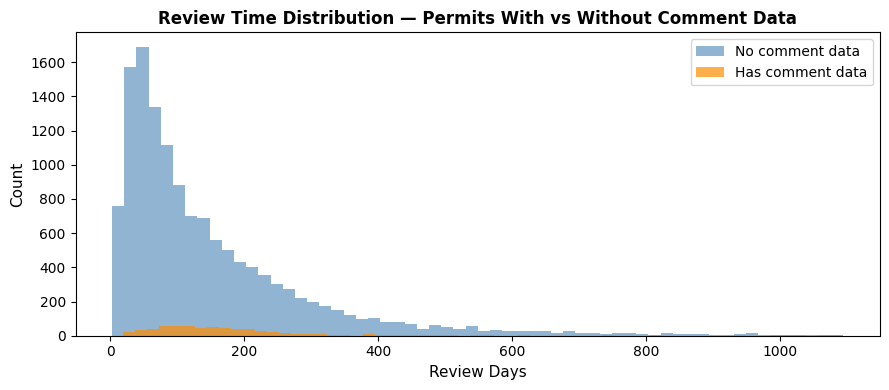

Saved: comment_coverage_distribution.png

Median review days — no comments : 99
Median review days — has comments: 152


In [10]:
# Visual: review time distribution for permits with vs without comments
has_mask = merged['comment_n_rows'].notna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(merged.loc[~has_mask, 'totaldaysplanreview'].dropna(),
        bins=60, alpha=0.6, color='steelblue', label='No comment data')
ax.hist(merged.loc[has_mask,  'totaldaysplanreview'].dropna(),
        bins=60, alpha=0.7, color='darkorange', label='Has comment data')
ax.set_xlabel('Review Days', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Review Time Distribution — Permits With vs Without Comment Data', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comment_coverage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comment_coverage_distribution.png')

print(f'\nMedian review days — no comments : {merged.loc[~has_mask, "totaldaysplanreview"].median():.0f}')
print(f'Median review days — has comments: {merged.loc[has_mask,  "totaldaysplanreview"].median():.0f}')

## 8. Save Output

In [11]:
output_path = OUTPUT_DIR / 'comment_features.csv'
comment_features.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape: {comment_features.shape}')
print(f'\nTo join onto master_dataset.csv:')
print(f'  df_master.merge(comment_features, on="permitnum", how="left")')
print(f'\nAll comment features will be null for permits without comment data.')
print(f'The model pipeline median-imputes these automatically via SimpleImputer.')

Saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\comment_features.csv
Shape: (707, 46)

To join onto master_dataset.csv:
  df_master.merge(comment_features, on="permitnum", how="left")

All comment features will be null for permits without comment data.
The model pipeline median-imputes these automatically via SimpleImputer.


## 9. Diagnostic Report

All outputs from sections 1–8 consolidated in one place for easy interpretation.

In [12]:
import datetime

sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — COMMENT FEATURE EXTRACTION REPORT')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Dataset Overview ───────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] DATASET OVERVIEW')
lines.append(sep2)
lines.append(f'  Source file          : plan_comments.csv')
lines.append(f'  Total comment rows   : {len(df):,}')
lines.append(f'  Unique permits       : {df["permitnum"].nunique():,}')
lines.append(f'  Permits in master    : {len(master):,}')
lines.append(f'  Coverage             : {has_comments:,} permits ({has_comments/len(merged)*100:.1f}%)')
lines.append(f'  No comment data      : {len(merged) - has_comments:,} permits (null-imputed by model)')
lines.append('')
lines.append('  Review cycle distribution:')
cycle_counts = df['reviewcycle'].value_counts().sort_index()
for cycle, count in cycle_counts.items():
    lines.append(f'    Cycle {int(cycle):>2}  {count:>6,} comments')

# ── 2. Review Type Distribution ───────────────────────────────────
lines.append('')
lines.append('[ 2 ] REVIEW TYPE DISTRIBUTION')
lines.append(sep2)
rt_counts = df['reviewtype'].value_counts()
for rt, count in rt_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct)
    lines.append(f'  {rt:<35} {count:>5,}  ({pct:>4.1f}%)  {bar}')

# ── 3. Structural Features Summary ───────────────────────────────
lines.append('')
lines.append('[ 3 ] STRUCTURAL FEATURES SUMMARY')
lines.append(sep2)
struct_desc = structural.drop('permitnum', axis=1).describe().round(3)
lines.append(f'  {struct_desc.to_string()}')

# ── 4. Text Feature Summary ───────────────────────────────────────
lines.append('')
lines.append('[ 4 ] TEXT-DERIVED FEATURE SUMMARY')
lines.append(sep2)
text_desc = text_feats.drop('permitnum', axis=1).describe().round(4)
lines.append(f'  {text_desc.to_string()}')
lines.append('')
lines.append('  Keyword hit counts (across all comment rows):')
for kw_col, label in [
    ('kw_repeated',   'repeated correction'),
    ('kw_unresolved', 'not resolved / not addressed'),
    ('kw_partial',    'partially resolved'),
    ('kw_resubmit',   'resubmit / revise'),
]:
    n = df[kw_col].sum()
    pct = n / len(df) * 100
    lines.append(f'    {label:<35} {int(n):>5,}  ({pct:.1f}% of rows)')

# ── 5. TF-IDF Terms ───────────────────────────────────────────────
lines.append('')
lines.append('[ 5 ] TF-IDF FEATURES EXTRACTED')
lines.append(sep2)
lines.append(f'  Total terms extracted: {len(tfidf_cols)}')
lines.append(f'  Ngram range          : (1, 2) — unigrams and bigrams')
lines.append(f'  Min document freq    : 5 permits')
lines.append('')
lines.append('  Terms (feature name → original term):')
for col, term in zip(tfidf_cols, tfidf.get_feature_names_out()):
    lines.append(f'    {col:<45}  "{term}"')

# ── 6. Signal Validation ──────────────────────────────────────────
lines.append('')
lines.append('[ 6 ] SIGNAL VALIDATION — CORRELATION WITH REVIEW TIME')
lines.append(sep2)
lines.append('  Pearson correlation of each structural/text feature with totaldaysplanreview:')
lines.append('  (computed only on the 707 permits that have comment data)')
lines.append('')
corr_sorted = corr.sort_values(ascending=False)
for feat, val in corr_sorted.items():
    bar = '█' * int(abs(val) * 40)
    direction = '+' if val >= 0 else '-'
    lines.append(f'  {feat:<45}  {val:>7.4f}  {direction}{bar}')

# ── 7. Coverage Impact ────────────────────────────────────────────
lines.append('')
lines.append('[ 7 ] COVERAGE IMPACT')
lines.append(sep2)
med_no  = merged.loc[~has_mask, 'totaldaysplanreview'].median()
med_yes = merged.loc[has_mask,  'totaldaysplanreview'].median()
lines.append(f'  Median review days — no comment data : {med_no:.0f}')
lines.append(f'  Median review days — has comment data: {med_yes:.0f}')
lines.append(f'  Ratio                                : {med_yes/med_no:.2f}x longer for permits with comments')
lines.append('')
lines.append('  This confirms selection bias: permits with comment data are systematically')
lines.append('  longer-running. Comment features will improve predictions for complex permits')
lines.append('  but coverage is too low (~5%) to meaningfully improve overall model metrics.')

# ── 8. Output Files ───────────────────────────────────────────────
lines.append('')
lines.append('[ 8 ] OUTPUT FILES')
lines.append(sep2)
for fname, desc in [
    ('comment_features.csv',              f'{len(comment_features):,} rows × {len(comment_features.columns)} columns — join onto master_dataset.csv on permitnum'),
    ('comment_coverage_distribution.png', 'Review time histogram: permits with vs without comment data'),
]:
    p = OUTPUT_DIR / fname
    exists = '✓' if p.exists() else '✗'
    lines.append(f'  {exists} {fname}')
    lines.append(f'    {desc}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

report_path = OUTPUT_DIR / 'DiagnosticReport_CommentFeatures.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')


  SEATTLE PERMIT PREDICTOR — COMMENT FEATURE EXTRACTION REPORT
  Generated: 2026-05-30 19:58:55

[ 1 ] DATASET OVERVIEW
----------------------------------------------------------------------
  Source file          : plan_comments.csv
  Total comment rows   : 26,299
  Unique permits       : 707
  Permits in master    : 14,201
  Coverage             : 665 permits (4.7%)
  No comment data      : 13,536 permits (null-imputed by model)

  Review cycle distribution:
    Cycle  1  18,958 comments
    Cycle  2   5,036 comments
    Cycle  3   1,545 comments
    Cycle  4     465 comments
    Cycle  5     135 comments
    Cycle  6      92 comments
    Cycle  7      34 comments
    Cycle  8      30 comments
    Cycle  9       2 comments
    Cycle 10       2 comments

[ 2 ] REVIEW TYPE DISTRIBUTION
----------------------------------------------------------------------
  Zoning                              5,999  (22.8%)  ██████████████████████
  Drainage                            4,536  (17.2%)  █

UnicodeEncodeError: 'charmap' codec can't encode characters in position 1092-1113: character maps to <undefined>